使用python脚本跑下面的代码来手动调整视角

图片已保存: probability_space_3d.png


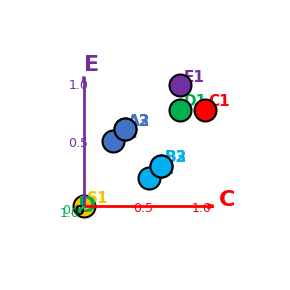

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 概率矩阵数据
cells = ['S1', 'A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'D1', 'E1']
prob_C = [0, 0.25, 0.35, 0.35, 0.55, 0.65, 0.65, 1, 0.8, 0.8]
prob_D = [0, 0.25, 0.35, 0.35, 0.55, 0.65, 0.65, 0.8, 1, 0.8]
prob_E = [0, 0.55, 0.65, 0.65, 0.25, 0.35, 0.35, 0.8, 0.8, 1]

# 定义颜色 - 与表格聚类颜色一致
colors_map = {
    'S': '#ffc000',    
    'A': '#4472c4',     
    'B': '#00b0f0',    
    'C': '#ff0000',   
    'D': '#00b050',    
    'E': '#7030a0'     
}
cell_colors = [colors_map[c[0]] for c in cells]

# 绘制3D散点图（透明背景，无网格线）
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')

# 关闭网格线
ax.grid(False)

# 关闭背景面板
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# 设置面板边框为透明
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# 隐藏默认的轴线和刻度
ax.set_axis_off()

# 绘制细胞点
for i, cell in enumerate(cells):
    ax.scatter(prob_D[i], prob_C[i], prob_E[i], 
               c=cell_colors[i], s=250, edgecolors='black', linewidth=1.5, zorder=5)
    ax.text(prob_D[i]+0.03, prob_C[i]+0.03, prob_E[i]+0.03, cell, 
            fontsize=11, fontweight='bold', color=cell_colors[i])

# 手动绘制从原点出发的三条坐标轴
axis_length = 1.1
# D轴 (X方向) - 加长
ax.quiver(0, 0, 0, axis_length, 0, 0, color='#00b050', arrow_length_ratio=0.05, linewidth=2)
ax.text(axis_length + 0.08, 0, 0, 'D', fontsize=16, fontweight='bold', color='#00b050')
# C轴 (Y方向)  
ax.quiver(0, 0, 0, 0, axis_length, 0, color='#ff0000', arrow_length_ratio=0.05, linewidth=2)
ax.text(0, axis_length + 0.05, 0, 'C', fontsize=16, fontweight='bold', color='#ff0000')
# E轴 (Z方向)
ax.quiver(0, 0, 0, 0, 0, axis_length, color='#7030a0', arrow_length_ratio=0.05, linewidth=2)
ax.text(0, 0, axis_length + 0.05, 'E', fontsize=16, fontweight='bold', color='#7030a0')

# 在轴上添加刻度标记
for tick in [0.5, 1.0]:
    # D轴刻度
    ax.plot([tick, tick], [0, 0], [0, 0], 'k-', linewidth=1)
    ax.text(tick, -0.08, -0.05, f'{tick}', fontsize=9, ha='center', color='#00b050')
    # C轴刻度
    ax.plot([0, 0], [tick, tick], [0, 0], 'k-', linewidth=1)
    ax.text(-0.08, tick, -0.05, f'{tick}', fontsize=9, ha='center', color='#ff0000')
    # E轴刻度
    ax.plot([0, 0], [0, 0], [tick, tick], 'k-', linewidth=1)
    ax.text(-0.08, -0.05, tick, f'{tick}', fontsize=9, ha='center', color='#7030a0')

# 标注原点
ax.text(-0.08, -0.08, -0.08, '0', fontsize=10, fontweight='bold', color='black')

# 调整坐标轴范围，让D轴显示更长
ax.set_xlim(-0.1, 1.5)  # D轴范围扩大
ax.set_ylim(-0.1, 1.2)
ax.set_zlim(-0.1, 1.2)

# 设置相同的纵横比，避免D轴被压缩
ax.set_box_aspect([1, 1, 1])  # D轴方向拉长

# # 添加图例
# legend_elements = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffc000', markersize=12, markeredgecolor='black', label='S (Root)'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#4472c4', markersize=12, markeredgecolor='black', label='A (Intermediate)'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#00b0f0', markersize=12, markeredgecolor='black', label='B (Intermediate)'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff0000', markersize=12, markeredgecolor='black', label='C (Terminal)'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#00b050', markersize=12, markeredgecolor='black', label='D (Terminal)'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#7030a0', markersize=12, markeredgecolor='black', label='E (Terminal)'),
# ]
# ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

# ax.set_title('Cell Distribution in Probability Space', fontsize=14, fontweight='bold')

# 视角
ax.view_init(elev=0, azim=0)

plt.tight_layout()
# 保存为透明背景的PNG
# plt.savefig('probability_space_3d.png', dpi=150, bbox_inches='tight', transparent=True)
# print("图片已保存: probability_space_3d.png")
plt.show()

In [58]:
help(ax.view_init)

Help on method view_init in module mpl_toolkits.mplot3d.axes3d:

view_init(elev=None, azim=None, roll=None, vertical_axis='z', share=False) method of mpl_toolkits.mplot3d.axes3d.Axes3D instance
    Set the elevation and azimuth of the Axes in degrees (not radians).
    
    This can be used to rotate the Axes programmatically.
    
    To look normal to the primary planes, the following elevation and
    azimuth angles can be used. A roll angle of 0, 90, 180, or 270 deg
    will rotate these views while keeping the axes at right angles.
    
    ==========   ====  ====
    view plane   elev  azim
    ==========   ====  ====
    XY           90    -90
    XZ           0     -90
    YZ           0     0
    -XY          -90   90
    -XZ          0     90
    -YZ          0     180
    ==========   ====  ====
    
    Parameters
    ----------
    elev : float, default: None
        The elevation angle in degrees rotates the camera above the plane
        pierced by the vertical axis, wit